In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import seaborn as sns


In [2]:
# Define parameters
batch_size = 32
img_height, img_width = 64, 64



In [5]:
train_datagen_german = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen_german = ImageDataGenerator(rescale=1.0/255.0)


In [6]:
# Create generators
train_generator_indian = train_datagen_indian.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\Indian\train',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

test_generator_indian = test_datagen_indian.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\Indian\test',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

train_generator_american = train_datagen_american.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\asl_dataset\Train',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

test_generator_american = test_datagen_american.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\asl_dataset\Test',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

train_generator_german = train_datagen_german.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\gsl\TRAINING',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

test_generator_german = test_datagen_german.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\gsl\TESTING',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

Found 45500 images belonging to 26 classes.
Found 9750 images belonging to 26 classes.
Found 151188 images belonging to 26 classes.
Found 2704 images belonging to 26 classes.
Found 3868 images belonging to 26 classes.
Found 1300 images belonging to 26 classes.


In [7]:
# Define the model for GSL
def create_model(input_shape, num_classes):
    model = Sequential()

    # Convolutional layers
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # Dropout layer to prevent overfitting
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


In [8]:
# Train the GSL model
model_gsl = create_model((img_height, img_width, 3), train_generator_german.num_classes)
history_german = model_gsl.fit(train_generator_german, validation_data=test_generator_german, epochs=50)

# Train the Indian Sign Language model
model_isl = create_model((img_height, img_width, 3), train_generator_indian.num_classes)
history_indian = model_isl.fit(train_generator_indian, validation_data=test_generator_indian, epochs=50)

# Train the American Sign Language model
model_asl = create_model((img_height, img_width, 3), train_generator_american.num_classes)
history_american = model_asl.fit(train_generator_american, validation_data=test_generator_american, epochs=50)


C:\Users\beraa\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\beraa\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.1047 - loss: 3.2065 - val_accuracy: 0.0708 - val_loss: 3.2262
Epoch 2/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.1463 - loss: 3.0306 - val_accuracy: 0.0762 - val_loss: 3.1732
Epoch 3/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.1779 - loss: 2.8030 - val_accuracy: 0.0538 - val_loss: 3.1474
Epoch 4/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.2276 - loss: 2.5318 - val_accuracy: 0.0385 - val_loss: 5.9533
Epoch 5/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.2977 - loss: 2.2169 - val_accuracy: 0.0462 - val_loss: 4.6200
Epoch 6/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.3226 - loss: 2.0300 - val_accuracy: 0.0408 - val_loss: 7.5148
Epoch 7/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.3994 - loss: 1.8394 - val_accuracy: 0.0369 - val_loss: 11.0484
Epoch 8/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.4423 - loss: 

KeyboardInterrupt: 

In [ ]:
# Function to plot accuracy and loss
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 6))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
# Plot training history for each language
plot_training_history(history_indian, 'Indian Sign Language')
plot_training_history(history_american, 'American Sign Language')
plot_training_history(history_german, 'German Sign Language')

# Save the models
model_isl.save('isl_model.keras')
model_asl.save('asl_model.keras')
model_gsl.save('gsl_model.keras')

print("Models saved successfully.")


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.regularizers import l2



In [21]:
# Define parameters
batch_size = 32
img_height, img_width = 64, 64

# Create ImageDataGenerators for training and testing with data augmentation
train_datagen_indian = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen_indian = ImageDataGenerator(rescale=1.0/255.0)

train_datagen_american = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen_american = ImageDataGenerator(rescale=1.0/255.0)

train_datagen_german = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen_german = ImageDataGenerator(rescale=1.0/255.0)


In [22]:
# Create generators
train_generator_indian = train_datagen_indian.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\Indian\train',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

test_generator_indian = test_datagen_indian.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\Indian\test',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

train_generator_american = train_datagen_american.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\asl_dataset\Train',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

test_generator_american = test_datagen_american.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\asl_dataset\Test',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

train_generator_german = train_datagen_german.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\gsl\TRAINING',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

test_generator_german = test_datagen_german.flow_from_directory(
    r'D:\capstone\SIGN LANGUAGE\DATASETS\gsl\TESTING',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse'
)

Found 45500 images belonging to 26 classes.
Found 9750 images belonging to 26 classes.
Found 153788 images belonging to 26 classes.
Found 104 images belonging to 26 classes.
Found 3868 images belonging to 26 classes.
Found 1300 images belonging to 26 classes.


In [23]:
def create_gsl_model(input_shape, num_classes):
    model = Sequential()

    # Convolutional layers
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))  # Dropout layer to prevent overfitting
    
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(optimizer=RMSprop(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [24]:
# Train the GSL model
model_gsl = create_gsl_model((img_height, img_width, 3), train_generator_german.num_classes)
history_german = model_gsl.fit(train_generator_german, validation_data=test_generator_german, epochs=50)


C:\Users\beraa\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\beraa\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - accuracy: 0.1480 - loss: 13.0878 - val_accuracy: 0.0385 - val_loss: 13.0057
Epoch 2/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.3601 - loss: 8.6388 - val_accuracy: 0.0385 - val_loss: 12.3234
Epoch 3/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.4844 - loss: 5.8710 - val_accuracy: 0.0385 - val_loss: 11.7347
Epoch 4/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.5707 - loss: 4.2528 - val_accuracy: 0.0738 - val_loss: 6.9923
Epoch 5/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.6197 - loss: 3.4275 - val_accuracy: 0.0385 - val_loss: 10.4739
Epoch 6/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.7041 - loss: 2.7465 - val_accuracy: 0.0400 - val_loss: 10.3816
Epoch 7/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.7170 - loss: 2.4321 - val_accuracy: 0.0531 - val_loss: 19.5030
Epoch 8/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.7447 - 

In [25]:
# Define the model for Indian Sign Language
def create_isl_model(input_shape, num_classes):
    model = Sequential()

    # Convolutional layers
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # Dropout layer to prevent overfitting
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [26]:
# Train the Indian Sign Language model
model_isl = create_isl_model((img_height, img_width, 3), train_generator_indian.num_classes)
history_indian = model_isl.fit(train_generator_indian, validation_data=test_generator_indian, epochs=50)

Epoch 1/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 77s 53ms/step - accuracy: 0.2092 - loss: 2.6717 - val_accuracy: 0.6099 - val_loss: 1.2525
Epoch 2/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.5323 - loss: 1.5374 - val_accuracy: 0.6839 - val_loss: 1.0126
Epoch 3/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 75s 52ms/step - accuracy: 0.5934 - loss: 1.3014 - val_accuracy: 0.7520 - val_loss: 0.8345
Epoch 4/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 107s 75ms/step - accuracy: 0.6345 - loss: 1.1426 - val_accuracy: 0.7880 - val_loss: 0.7038
Epoch 5/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 138s 97ms/step - accuracy: 0.6761 - loss: 1.0197 - val_accuracy: 0.7804 - val_loss: 0.6726
Epoch 6/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 135s 95ms/step - accuracy: 0.6961 - loss: 0.9473 - val_accuracy: 0.8307 - val_loss: 0.5559
Epoch 7/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 136s 95ms/step - accuracy: 0.7235 - loss: 0.8636 - val_accuracy: 0.8574 - val_loss: 0.4849
Epoch 8/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 137s 96ms/step - accuracy: 0.7

In [27]:
# Define the model for American Sign Language
def create_asl_model(input_shape, num_classes):
    model = Sequential()

    # Convolutional layers
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # Dropout layer to prevent overfitting
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


In [28]:
# Train the American Sign Language model
model_asl = create_asl_model((img_height, img_width, 3), train_generator_american.num_classes)
history_american = model_asl.fit(train_generator_american, validation_data=test_generator_american, epochs=50)


Epoch 1/50
4806/4806 ━━━━━━━━━━━━━━━━━━━━ 309s 64ms/step - accuracy: 0.5180 - loss: 1.4674 - val_accuracy: 1.0000 - val_loss: 0.0239
Epoch 2/50
4806/4806 ━━━━━━━━━━━━━━━━━━━━ 286s 60ms/step - accuracy: 0.9027 - loss: 0.2815 - val_accuracy: 1.0000 - val_loss: 1.4604e-04
Epoch 3/50
4806/4806 ━━━━━━━━━━━━━━━━━━━━ 287s 60ms/step - accuracy: 0.9479 - loss: 0.1571 - val_accuracy: 1.0000 - val_loss: 6.1085e-05
Epoch 4/50
4806/4806 ━━━━━━━━━━━━━━━━━━━━ 289s 60ms/step - accuracy: 0.9684 - loss: 0.0992 - val_accuracy: 1.0000 - val_loss: 1.2219e-04
Epoch 5/50
4806/4806 ━━━━━━━━━━━━━━━━━━━━ 288s 60ms/step - accuracy: 0.9762 - loss: 0.0732 - val_accuracy: 1.0000 - val_loss: 6.6088e-04
Epoch 6/50
4806/4806 ━━━━━━━━━━━━━━━━━━━━ 288s 60ms/step - accuracy: 0.9814 - loss: 0.0617 - val_accuracy: 1.0000 - val_loss: 4.0118e-08
Epoch 7/50
4806/4806 ━━━━━━━━━━━━━━━━━━━━ 287s 60ms/step - accuracy: 0.9841 - loss: 0.0530 - val_accuracy: 1.0000 - val_loss: 1.0763e-06
Epoch 8/50
4806/4806 ━━━━━━━━━━━━━━━━━━━━ 289

In [35]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 6))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


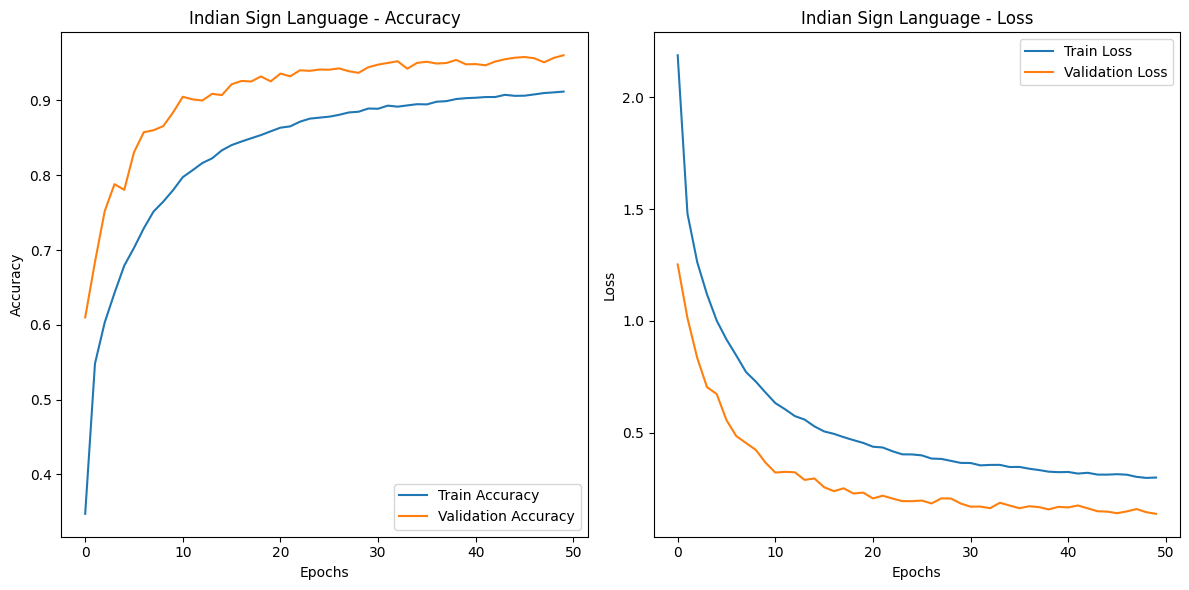

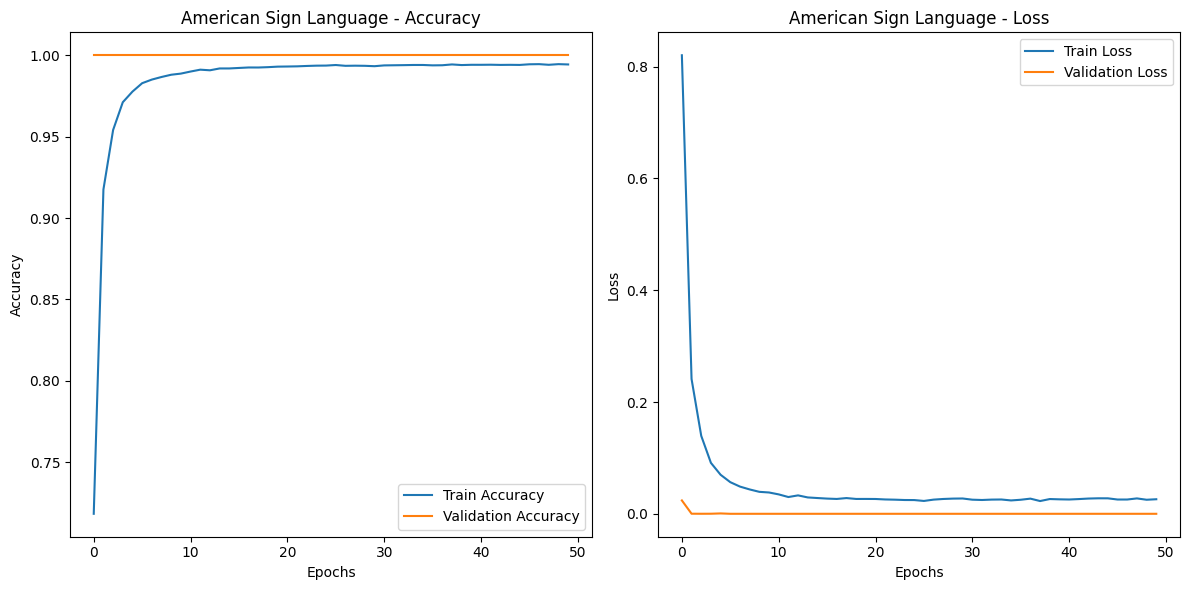

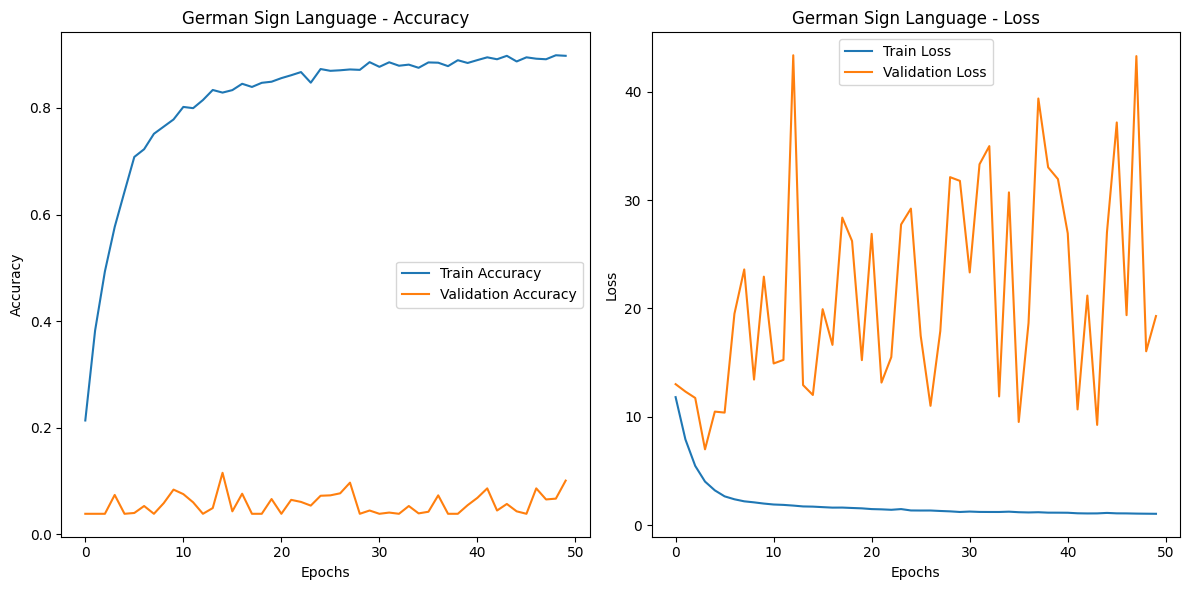

Models saved successfully.


In [36]:
plot_training_history(history_indian, 'Indian Sign Language')
plot_training_history(history_american, 'American Sign Language')
plot_training_history(history_german, 'German Sign Language')

# Save the models
model_isl.save('isl_model.keras')
model_asl.save('asl_model.keras')
model_gsl.save('gsl_model.keras')

print("Models saved successfully.")